# Spring of Code - Artificial Intelligence

## Week 08: Deep Learning

### Day 02: Transfer Learning for Medical Imaging (Chest CT Scans)

Welcome to this comprehensive tutorial on **Transfer Learning**. In this lengthy notebook, we will focus on applying deep learning to a real-world medical problem: classifying Chest CT scan images for different lung cancer conditions.

**Our Objectives for Today:**
1. **Dataset Handling in Code**: Programmatically download a dataset from Kaggle using `kagglehub` and copy it into our local working directory.
2. **Data Preprocessing**: Prepare and augment medical image data using Keras's data generators.
3. **Transfer Learning via Feature Extraction**: Use three distinct pre-trained CNN architectures (VGG16, MobileNetV2, and ResNet50) as fixed feature extractors to train over our custom CT scan data.
4. **Visual Analysis**: Monitor the learning process with custom graphs.
5. **Model Comparison**: Evaluate our three transfer learning models side-by-side to understand which architecture is best for this specific problem.
6. **Fine-Tuning**: Go beyond feature extraction, unfreeze layers of our best model, and re-train it with a low learning rate to optimize performance.

By the end of this notebook, you'll understand why Transfer Learning is arguably the most essential technique in modern applied AI!

---
## 1. Setup, Package Installation, and Imports

First, we will ensure that `kagglehub` is installed, as we'll use it to download our dataset directly into the notebook. Then, we'll import the deep learning libraries needed.

In [1]:
import os
import shutil
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50
from sklearn.metrics import confusion_matrix

# Ensure robust GPU memory allocation if a GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Memory Growth Enabled for {len(gpus)} GPU(s).")
    except RuntimeError as e:
        print(e)

print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

c:\Users\DIPLAB\.conda\envs\tf-ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU Memory Growth Enabled for 1 GPU(s).
TensorFlow Version: 2.10.1
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. Download and Copy the Dataset

The dataset we are using is the **Chest CT-Scan images Dataset** (`mohamedhanyyy/chest-ctscan-images`).
This dataset contains images categorizing cases into normal, adenocarcinoma, large cell carcinoma, and squamous cell carcinoma.

We will download it using `kagglehub.dataset_download()` which puts it in a cache folder. Then we will copy that cache folder into a local `./dataset` folder right in our current directory, so it's readily accessible!

In [2]:
# print("Downloading Chest CT Scan Dataset...")
# Download latest version of the dataset
# cache_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
# print("Downloaded to cache directory:", cache_path)

# Target directory in the current working directory
target_dataset_dir = "./dataset"

# if not os.path.exists(target_dataset_dir):
#     # print(f"Copying dataset to {target_dataset_dir} ... This might take a moment.")
#     shutil.copytree(cache_path, target_dataset_dir)
#     print("Copy complete!")
# else:
#     print(f"Dataset already exists locally at {target_dataset_dir} - Skipping copy step.")

# Let's identify the actual train/test/valid paths
train_dir = None
test_dir = None
val_dir = None

for root, dirs, files in os.walk(target_dataset_dir):
    # Standard medical datasets on Kaggle usually have train/test/valid splits
    if 'train' in dirs and 'test' in dirs and 'valid' in dirs:
        train_dir = os.path.join(root, 'train')
        test_dir = os.path.join(root, 'test')
        val_dir = os.path.join(root, 'valid')
        break

print(f"\nTrain Directory: {train_dir}")
print(f"Test Directory: {test_dir}")
print(f"Validation Directory: {val_dir}")


Train Directory: ./dataset\Data\train
Test Directory: ./dataset\Data\test
Validation Directory: ./dataset\Data\valid


---
## 3. Data Preprocessing and Augmentation

In deep learning, neural networks require inputs of the exact same size. Furthermore, medical datasets are usually very small (a few hundred images). Training complicated neural networks on small datasets directly will cause massive **overfitting**.

To solve this, we use:
1. **Transfer Learning**: Utilizing pre-trained network weights to extract features.
2. **Data Augmentation**: Applying tiny alterations (zoom, flip, tiny rotations) dynamically during training so the network never sees the exact same image twice!

We will set our images to **224x224**, which is standard for most modern pre-trained classification networks.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FE = 10  # Epochs for Feature Extraction

# Define physical parameters for Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values [0, 255] -> [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test data MUST NOT be augmented! Just rescaled.
test_val_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data...")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # Standard for multi-class classification
)

print("\nLoading Validation Data...")
val_data = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nLoading Testing Data...")
test_data = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False             # DO NOT shuffle test data; keep order for proper metric evaluation
)

# Grab the dictionary that maps folder names to integer class indices
class_indices = train_data.class_indices
classes = list(class_indices.keys())
NUM_CLASSES = len(classes)
print(f"\nTotal Number of Classes: {NUM_CLASSES}")
print(f"Class dictionary: {class_indices}")

Loading Training Data...
Found 613 images belonging to 4 classes.

Loading Validation Data...
Found 72 images belonging to 4 classes.

Loading Testing Data...
Found 315 images belonging to 4 classes.

Total Number of Classes: 4
Class dictionary: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


In [23]:
train_data.class_indices

{'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0,
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1,
 'normal': 2,
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}

### Visualize Processed Images
Let's see what a batch of augmented data looks like to give you a sense of what the CNN will be "looking" at.

In [5]:
next(train_data)

(array([[[[1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
 
         [[1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
 
         [[1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          [1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+

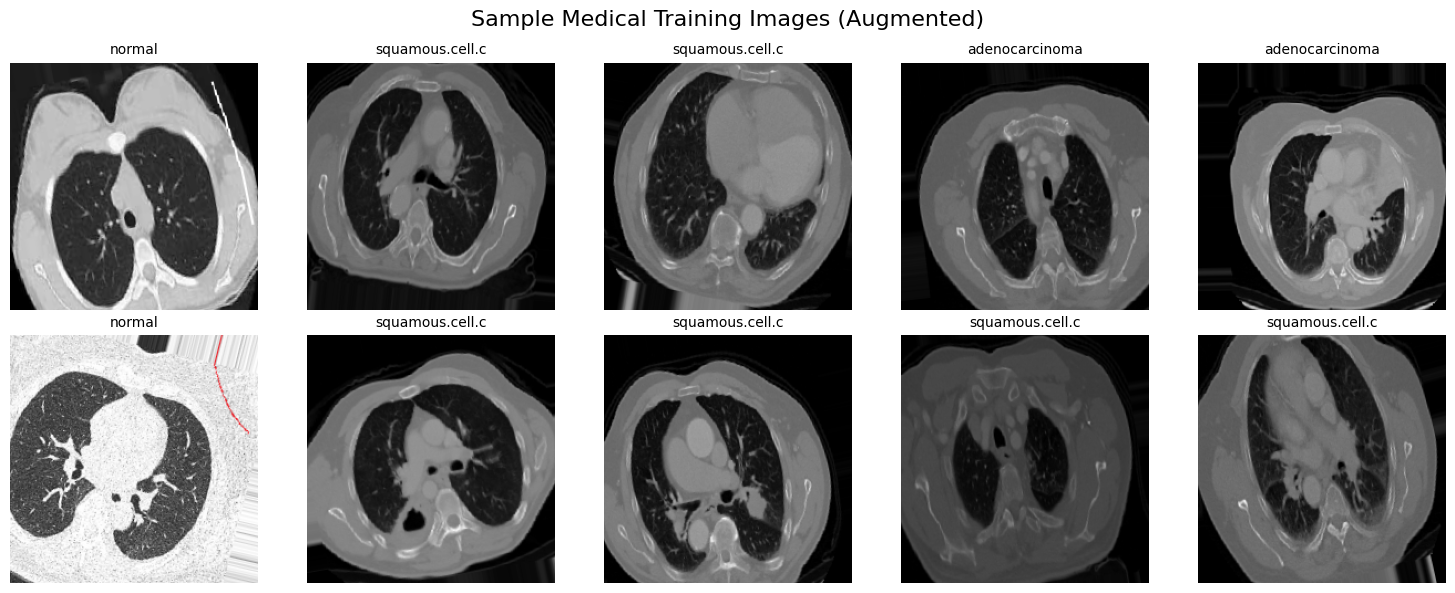

In [4]:
images, labels = next(train_data)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    class_idx = np.argmax(labels[i])
    # Creating short titles to fit nicely
    short_label = classes[class_idx].split('_')[0][:15]
    plt.title(short_label, fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Medical Training Images (Augmented)', fontsize=16)
plt.tight_layout()
plt.show()

---
## 4. Modeling Strategy

In **Transfer Learning**, our goal is to load a large, very complex network that has already learned to "see" shapes, edges, borders, textures, and patterns using a monumental dataset like ImageNet (1.2 million images). 

If we chop off the "head" (the final classification layers) of this network, what we are left with is a highly capable "feature extractor loop". We append our own small Dense layers at the end to classify our custom CT scans instead of cats and dogs.

First, we will define a handy plot function that we can reuse multiple times to see the training behavior.

In [6]:
def plot_learning_curves(history, model_name):
    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracies
    ax1.plot(history.history['accuracy'], label='Train Acc', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Val Acc', marker='s')
    ax1.set_title(f'{model_name} Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Losses
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Val Loss', marker='s')
    ax2.set_title(f'{model_name} Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

---
## 5. Experiment 1: VGG16 as Feature Extractor

VGG16 is a classic deep learning architecture. It is notoriously "heavy" in parameters but performs extraordinarily well. Let's build a transfer learning pipeline using it.

In [7]:
IMG_SIZE

(224, 224)

In [8]:
# Load Pre-Trained VGG16 WITHOUT the Top Classification Layers
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# FREEZE the base so its pre-trained weights cannot be damaged by our random initialization gradient changes!
vgg_base.trainable = False

# Create Sequential Model utilizing the fixed extractor
model_vgg = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),    # Converts multi-dimensional feature map to single dense array
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),                # Regulate to prevent overfitting
    layers.Dense(NUM_CLASSES, activation='softmax') # Multi-class probability head 
], name="VGG16_Transfer")

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "VGG16_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 14,847,044
Trainable params: 132,356
Non-trainable params: 14,714,688
__________________________________

In [9]:
print("Training VGG16 Feature Extractor...")
history_vgg = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FE
)

Training VGG16 Feature Extractor...
Epoch 1/10
20/20 [==============================] - 30s 880ms/step - loss: 1.4010 - accuracy: 0.3442 - val_loss: 1.3117 - val_accuracy: 0.4583
Epoch 2/10
20/20 [==============================] - 10s 479ms/step - loss: 1.1933 - accuracy: 0.4421 - val_loss: 1.1806 - val_accuracy: 0.5278
Epoch 3/10
20/20 [==============================] - 10s 472ms/step - loss: 1.0463 - accuracy: 0.5122 - val_loss: 1.0665 - val_accuracy: 0.5000
Epoch 4/10
20/20 [==============================] - 10s 476ms/step - loss: 0.9998 - accuracy: 0.5530 - val_loss: 0.9895 - val_accuracy: 0.6389
Epoch 5/10
20/20 [==============================] - 10s 484ms/step - loss: 0.9324 - accuracy: 0.5775 - val_loss: 0.9993 - val_accuracy: 0.5000
Epoch 6/10
20/20 [==============================] - 10s 480ms/step - loss: 0.9316 - accuracy: 0.5628 - val_loss: 1.0135 - val_accuracy: 0.4861
Epoch 7/10
20/20 [==============================] - 10s 498ms/step - loss: 0.8927 - accuracy: 0.5922 - val

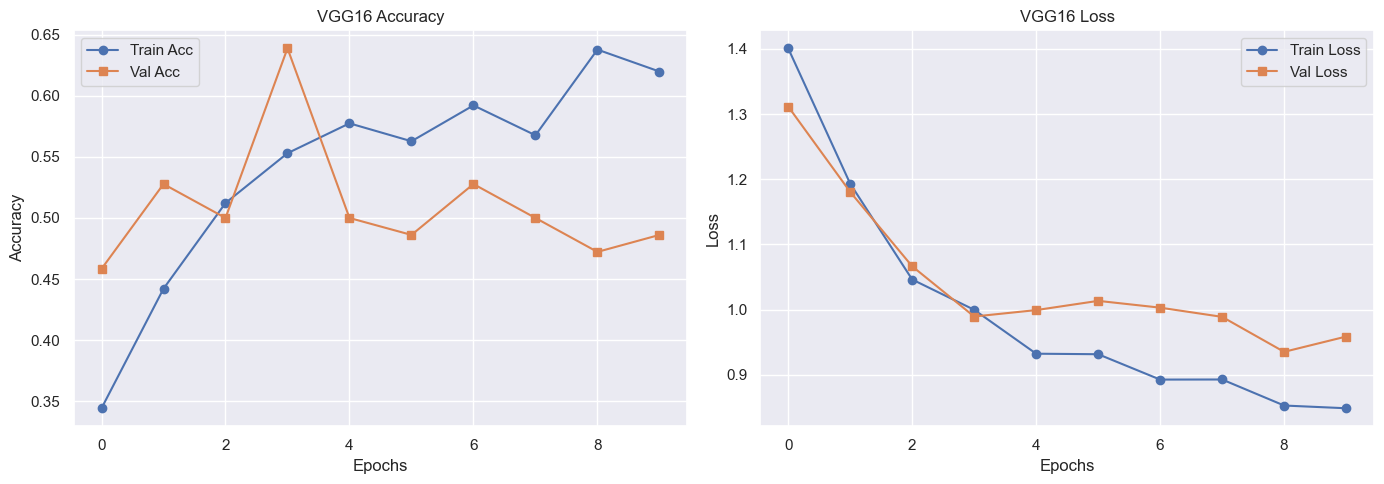

In [10]:
plot_learning_curves(history_vgg, "VGG16")

---
## 6. Experiment 2: MobileNetV2 as Feature Extractor

MobileNetV2 is designed for mobile efficiency. It utilizes deeply separable convolutions, making it lightweight containing way fewer parameters but often delivering similar accuracy faster!

In [11]:
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
mobilenet_base.trainable = False

model_mobilenet = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="MobileNetV2_Transfer")

model_mobilenet.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

Model: "MobileNetV2_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 2,586,948
Trainable params: 328,

In [12]:
print("Training MobileNetV2 Feature Extractor...")
history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FE
)

Training MobileNetV2 Feature Extractor...
Epoch 1/10
20/20 [==============================] - 15s 523ms/step - loss: 1.2818 - accuracy: 0.5008 - val_loss: 0.9867 - val_accuracy: 0.4583
Epoch 2/10
20/20 [==============================] - 9s 448ms/step - loss: 0.8799 - accuracy: 0.5791 - val_loss: 0.8576 - val_accuracy: 0.5833
Epoch 3/10
20/20 [==============================] - 9s 445ms/step - loss: 0.7130 - accuracy: 0.6672 - val_loss: 0.8496 - val_accuracy: 0.6111
Epoch 4/10
20/20 [==============================] - 9s 452ms/step - loss: 0.6077 - accuracy: 0.7439 - val_loss: 0.8914 - val_accuracy: 0.6250
Epoch 5/10
20/20 [==============================] - 9s 445ms/step - loss: 0.5995 - accuracy: 0.7325 - val_loss: 0.8135 - val_accuracy: 0.6667
Epoch 6/10
20/20 [==============================] - 9s 456ms/step - loss: 0.5274 - accuracy: 0.7945 - val_loss: 0.7845 - val_accuracy: 0.7083
Epoch 7/10
20/20 [==============================] - 9s 465ms/step - loss: 0.4918 - accuracy: 0.7879 - val

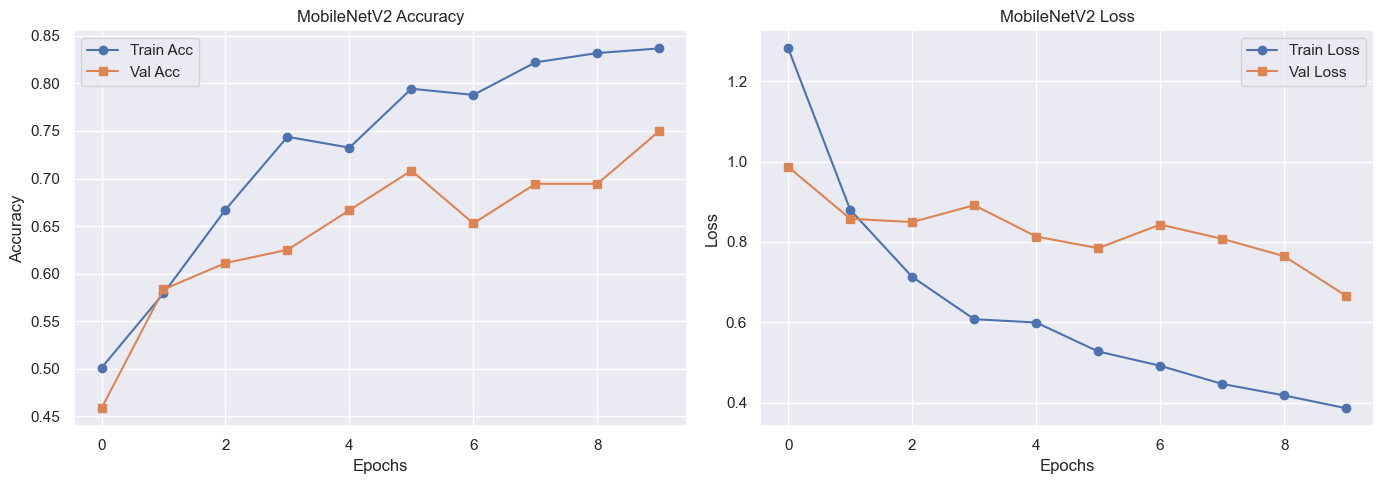

In [13]:
plot_learning_curves(history_mobilenet, "MobileNetV2")

---
## 7. Experiment 3: ResNet50 as Feature Extractor

ResNet50 uses "Residual skip connections" that allows the gradient to skip layers. This solved the vanishing gradient problem, allowing architectures to go massively "deep" (50+ layers).


In [14]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
resnet_base.trainable = False

model_resnet = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="ResNet50_Transfer")

model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "ResNet50_Transfer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 256)               524544    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 24,113,284
Trainable params: 525,572
Non-trainable params: 23,587,712
_______________________________

In [15]:
print("Training ResNet50 Feature Extractor...")
history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FE
)

Training ResNet50 Feature Extractor...
Epoch 1/10
20/20 [==============================] - 17s 576ms/step - loss: 1.4315 - accuracy: 0.3736 - val_loss: 1.1600 - val_accuracy: 0.4861
Epoch 2/10
20/20 [==============================] - 10s 480ms/step - loss: 1.1651 - accuracy: 0.4437 - val_loss: 1.0192 - val_accuracy: 0.4861
Epoch 3/10
20/20 [==============================] - 10s 471ms/step - loss: 1.0535 - accuracy: 0.5204 - val_loss: 1.0081 - val_accuracy: 0.4861
Epoch 4/10
20/20 [==============================] - 10s 474ms/step - loss: 1.0257 - accuracy: 0.5285 - val_loss: 1.0244 - val_accuracy: 0.4583
Epoch 5/10
20/20 [==============================] - 10s 490ms/step - loss: 1.0123 - accuracy: 0.5008 - val_loss: 1.0403 - val_accuracy: 0.4861
Epoch 6/10
20/20 [==============================] - 10s 514ms/step - loss: 1.0308 - accuracy: 0.4894 - val_loss: 1.0035 - val_accuracy: 0.4722
Epoch 7/10
20/20 [==============================] - 10s 514ms/step - loss: 1.0039 - accuracy: 0.5383 - 

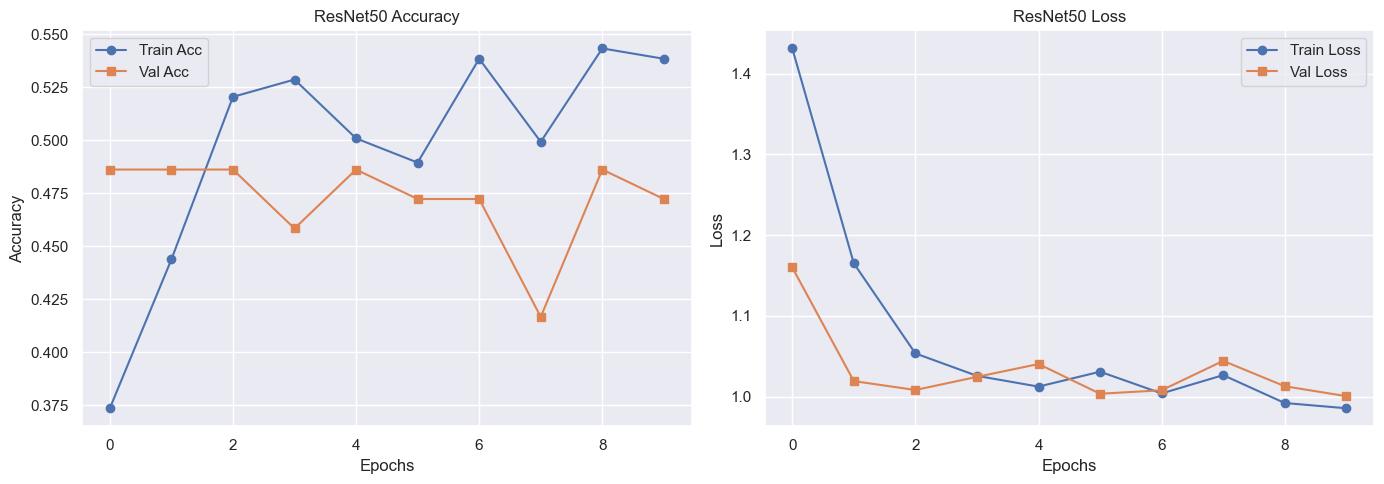

In [16]:
plot_learning_curves(history_resnet, "ResNet50")

---
## 8. Model Comparison and Evaluation

Now that all three models are trained under identical conditions on the same dataset, we rigorously test them on our holdout `test_data` which none of the models have ever seen.

In [17]:
print("Evaluating VGG16...")
vgg_loss, vgg_acc = model_vgg.evaluate(test_data)

print("\nEvaluating MobileNetV2...")
mobile_loss, mobile_acc = model_mobilenet.evaluate(test_data)

print("\nEvaluating ResNet50...")
resnet_loss, resnet_acc = model_resnet.evaluate(test_data)

Evaluating VGG16...
10/10 [==============================] - 11s 1s/step - loss: 1.0584 - accuracy: 0.5333

Evaluating MobileNetV2...
10/10 [==============================] - 2s 227ms/step - loss: 0.5973 - accuracy: 0.7397

Evaluating ResNet50...
10/10 [==============================] - 2s 236ms/step - loss: 0.9510 - accuracy: 0.5429


C:\Users\DIPLAB\AppData\Local\Temp\ipykernel_7700\1900688409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


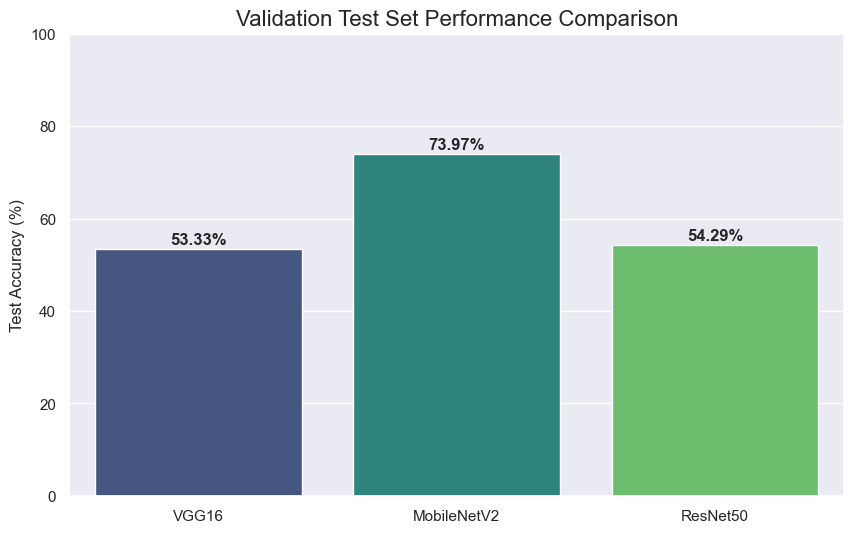

In [18]:
# Simple Bar Chart to compare test accuracies
model_names = ['VGG16', 'MobileNetV2', 'ResNet50']
accuracies = [vgg_acc * 100, mobile_acc * 100, resnet_acc * 100]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies, palette="viridis")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)
    
plt.ylim(0, 100)
plt.title('Validation Test Set Performance Comparison', fontsize=16)
plt.ylabel('Test Accuracy (%)')
plt.show()

---
## 9. Stage 2: Fine-Tuning the Best Model

In the previous steps, we froze the entire feature extraction base. As a result, the network used pre-set visual primitives designed for ImageNet content.

**Fine-Tuning** is an advanced strategy where, after the multi-class Head is stable, we UNFREEZE the top 20% or 30% layers of our base. We then train again with an extremely small learning rate (to prevent shattering the pre-trained weights). This process adapts high-level feature filters perfectly to the distinct properties of CT scans.

In [19]:
# Example: We'll fine-tune MobileNetV2 (Assuming it was efficient/effective in initial tests)
# You can modify this to pick whichever model performed best natively
best_model_base = mobilenet_base
best_full_model = model_mobilenet

# UNFREEZE the base
best_model_base.trainable = True

# See how many layers are in the base
total_layers = len(best_model_base.layers)
print(f"Total layers in MobileNet base: {total_layers}")

# Let's freeze the first 10 layers and leave the rest trainable
fine_tune_at = 10
for layer in best_model_base.layers[:fine_tune_at]:
    layer.trainable = False

# Essential: Use an exceptionally tiny learning rate
best_full_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # 1/100th of previous LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

best_full_model.summary()

Total layers in MobileNet base: 154
Model: "MobileNetV2_Transfer"


_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 2,586,948
Trainable params: 2,549,476
Non-trainable params: 37

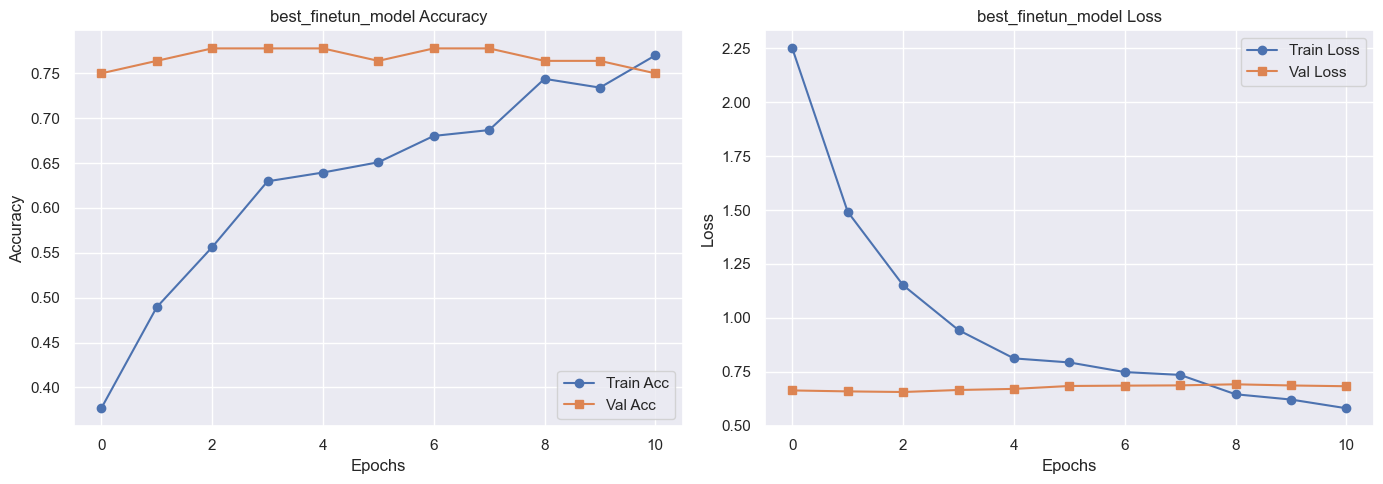

In [23]:
plot_learning_curves(history_finetune, 'best_finetun_model')

In [20]:
EPOCHS_FINETUNE = 10

print("Starting Fine-Tuning Training Process...")
history_finetune = best_full_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_FE + EPOCHS_FINETUNE, # Total 20 epochs
    initial_epoch=history_mobilenet.epoch[-1] # Resume from epoch 10
)

Starting Fine-Tuning Training Process...
Epoch 10/20
20/20 [==============================] - 18s 538ms/step - loss: 2.2493 - accuracy: 0.3768 - val_loss: 0.6634 - val_accuracy: 0.7500
Epoch 11/20
20/20 [==============================] - 10s 516ms/step - loss: 1.4916 - accuracy: 0.4894 - val_loss: 0.6590 - val_accuracy: 0.7639
Epoch 12/20
20/20 [==============================] - 10s 494ms/step - loss: 1.1512 - accuracy: 0.5563 - val_loss: 0.6561 - val_accuracy: 0.7778
Epoch 13/20
20/20 [==============================] - 10s 498ms/step - loss: 0.9432 - accuracy: 0.6297 - val_loss: 0.6655 - val_accuracy: 0.7778
Epoch 14/20
20/20 [==============================] - 11s 528ms/step - loss: 0.8120 - accuracy: 0.6395 - val_loss: 0.6705 - val_accuracy: 0.7778
Epoch 15/20
20/20 [==============================] - 12s 573ms/step - loss: 0.7932 - accuracy: 0.6509 - val_loss: 0.6841 - val_accuracy: 0.7639
Epoch 16/20
20/20 [==============================] - 10s 515ms/step - loss: 0.7486 - accuracy: 

---
## 10. Advanced Analytics: Confusion Matrix

Accuracy tells us how often the model is "correct." But it doesn't tell us *what specific mistakes it is making*. To understand that, we build a **Confusion Matrix**.

10/10 [==============================] - 3s 182ms/step


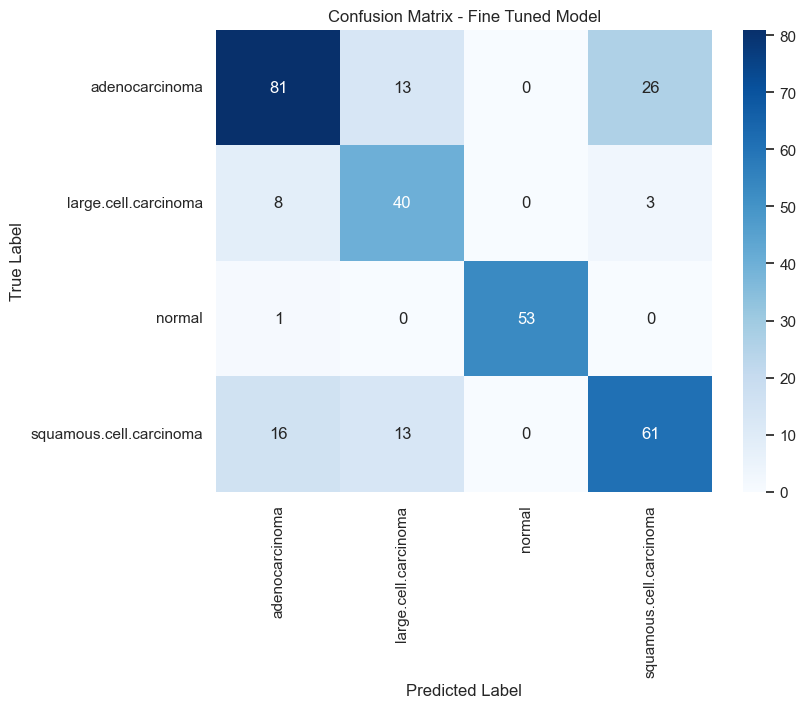

In [21]:
# To generate a Confusion Matrix, we predict across the entire test set.
test_data.reset() # Important to assure matching with exact file order
predictions = best_full_model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[c.split('_')[0] for c in classes], 
            yticklabels=[c.split('_')[0] for c in classes])
plt.title('Confusion Matrix - Fine Tuned Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Conclusion!
Today, we discovered the absolute dominance of Transfer Learning.
We successfully utilized code to grab data from the internet seamlessly, structured medical CT Scans to train custom Deep Neural Networks, learned how to analyze validation graphs, assessed model architectural performances visually, and advanced our pipeline through Deep Fine-Tuning!

In [24]:
best_full_model.save('ct_model.keras')